# Analiza stabilnosci wynikow szkol

Cel: sprawdzic, jak zmiennosc (niestabilnosc) median wynikow z jezyka polskiego, matematyki i angielskiego zalezy od rozmiaru szkoly.


In [1]:
# Notebook uruchamiaj po starcie JupyterLab z uv:
# uv venv && uv sync && uv run jupyter lab

In [2]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')

DATA_DIR = Path('../data/egzamin-osmoklasisty')
YEAR_FILE_RE = re.compile(r'^\d{4}.*\.xlsx(?:\.xlsx)?$', re.IGNORECASE)


# Bierzemy tylko pliki zaczynajace sie od 4 cyfr roku.
files = sorted(p for p in DATA_DIR.glob('*.xlsx*') if YEAR_FILE_RE.match(p.name))
assert files, 'Nie znaleziono plikow rozpoczynajacych sie od roku (YYYY...).'


def normalize_text(text: str) -> str:
    text = unicodedata.normalize('NFKD', text)
    text = ''.join(ch for ch in text if not unicodedata.combining(ch))
    text = text.replace('\n', ' ')
    return re.sub(r'\s+', ' ', text).lower().strip()


def extract_year(file_name: str) -> int:
    m = re.match(r'^(\d{4})', file_name)
    if not m:
        raise ValueError(f'Nazwa pliku nie zaczyna sie od roku: {file_name}')
    return int(m.group(1))


def clean_header_value(value: object) -> str:
    if value is None:
        return ''
    text = str(value)
    if text.startswith('Unnamed:') or text == 'nan':
        return ''
    return re.sub(r'\s+', ' ', text.replace('\n', ' ')).strip()


def normalize_multiindex_columns(columns: pd.MultiIndex) -> pd.MultiIndex:
    # W arkuszach sa scalone komorki; puste wartosci w poziomie 1 uzupelniamy poprzednia wartoscia.
    lvl0_values = []
    lvl1_values = []
    last_lvl0 = 'meta'

    for raw0, raw1 in columns.to_list():
        lvl0_raw = clean_header_value(raw0)
        lvl1_raw = clean_header_value(raw1)

        if lvl0_raw:
            last_lvl0 = normalize_text(lvl0_raw)
            lvl0 = last_lvl0
        else:
            lvl0 = last_lvl0

        lvl1 = normalize_text(lvl1_raw) if lvl1_raw else 'wartosc'

        lvl0_values.append(lvl0)
        lvl1_values.append(lvl1)

    return pd.MultiIndex.from_arrays([lvl0_values, lvl1_values], names=['obszar', 'metryka'])


def read_exam_file(path: Path) -> pd.DataFrame:
    # Dane szkol sa w arkuszu 'SAS' (w 2022+ pierwszy arkusz to tylko legenda).
    df = pd.read_excel(path, sheet_name='SAS', header=[0, 1])
    df.columns = normalize_multiindex_columns(df.columns)
    return df


def has_mediana_columns(columns: pd.MultiIndex) -> bool:
    for lvl0, lvl1 in columns.to_list():
        joined = f'{lvl0} {lvl1}'
        if 'mediana' in normalize_text(joined):
            return True
    return False


def choose_polish_candidates_col(columns: pd.MultiIndex) -> tuple[str, str]:
    # Interesuje nas liczba zdajacych dla polskiego.
    for lvl0, lvl1 in columns.to_list():
        n0 = normalize_text(lvl0)
        n1 = normalize_text(lvl1)
        joined = f'{n0} {n1}'
        if 'polsk' in joined and 'liczba' in joined and ('zdaj' in joined or 'uczni' in joined):
            return (lvl0, lvl1)
    raise ValueError('Nie znaleziono kolumny z liczba zdajacych dla jezyka polskiego.')


files

[PosixPath('../data/egzamin-osmoklasisty/2021 - bip_1266e8-2021-wyniki-szkoly__SAS.xlsx.xlsx'),
 PosixPath('../data/egzamin-osmoklasisty/2022 - bip_1466okewaw_wyniki_e8_szkoly_aktl_wrzesien.xlsx.xlsx'),
 PosixPath('../data/egzamin-osmoklasisty/2023 - bip_1590e8-2023-okewaw--wyniki-szkoly-glowna-sas.xlsx.xlsx'),
 PosixPath('../data/egzamin-osmoklasisty/2024 - bip_1777OKEWAW_Wyniki_E8_szkoly.xlsx.xlsx'),
 PosixPath('../data/egzamin-osmoklasisty/2025 - OKEWAW-Wyniki-E8-szkoly-lipiec.xlsx')]

## Sklejony zbior `df_egzaminy`

Ladujemy tylko pliki roczne (`YYYY...`), sprawdzamy czy wszystkie maja ten sam format
(te same kolumny w tej samej kolejnosci), a potem sklejamy je do jednego DataFrame z kolumna `rok` na poczatku.

In [3]:
frames = []
reference_cols = None
reference_file = None


def is_optional_col(col: tuple[str, str]) -> bool:
    # Ta kolumna bywa tylko w czesci lat.
    metryka_norm = normalize_text(col[1]).replace('ł', 'l')
    return 'identyfikator szkoly' in metryka_norm


for path in files:
    year = extract_year(path.name)
    df = read_exam_file(path)

    if not has_mediana_columns(df.columns):
        raise ValueError(f'Plik nie zawiera kolumn z mediana: {path.name}')

    if reference_cols is None:
        reference_cols = df.columns
        reference_file = path.name
    else:
        missing_vs_ref = sorted(set(reference_cols) - set(df.columns))
        extra_vs_ref = sorted(set(df.columns) - set(reference_cols))

        missing_non_optional = [c for c in missing_vs_ref if not is_optional_col(c)]
        extra_non_optional = [c for c in extra_vs_ref if not is_optional_col(c)]

        if missing_non_optional or extra_non_optional:
            raise ValueError(
                'Niezgodny format kolumn (poza dozwolona kolumna opcjonalna). '
                f'Plik referencyjny: {reference_file}; plik problematyczny: {path.name}; '
                f'brakujace: {missing_non_optional}; dodatkowe: {extra_non_optional}'
            )

    # Dokladamy rok jako pierwsza kolumne, tez w strukturze 2-poziomowej.
    df.insert(0, ('meta', 'rok'), year)
    frames.append(df)

# Glowny DataFrame: zachowujemy MultiIndex kolumn (2 poziomy).
# Kolumna opcjonalna pojawi sie z NaN tam, gdzie nie wystepuje.
df_egzaminy = pd.concat(frames, ignore_index=True, sort=False)

polish_candidates_col = choose_polish_candidates_col(df_egzaminy.columns)

df_egzaminy.head()

obszar   meta                                                          \
metryka   rok id oke wojewodztwo - nazwa powiat - nazwa gmina - nazwa   
0        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
1        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
2        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
3        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
4        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   

obszar                                                                       \
metryka      typ gminy kod teryt gminy   rspo rodzaj placowki czy publiczna   
0        Gmina miejska         1461011  27152   dla młodzieży           Tak   
1        Gmina miejska         1461011  27351   dla młodzieży           Tak   
2        Gmina miejska         1461011  27789   dla młodzieży           Tak   
3        Gmina miejska         1461011  44013   dla młodzieży           Tak   
4        Gmina miejska         1461011  44015   dla młodzieży           Tak   

obszar   ...   jezyk rosyjski                                         \
metryka  ... wynik sredni (%) odchylenie standardowe (%) mediana (%)   
0        ...              NaN                        NaN         NaN   
1        ...              NaN                        NaN         NaN   
2        ...              NaN                        NaN         NaN   
3        ...              NaN                        NaN         NaN   
4        ...              NaN                        NaN         NaN   

obszar                  jezyk włoski                   \
metryka modalna (%) liczba zdajacych wynik sredni (%)   
0               NaN              NaN              NaN   
1               NaN              NaN              NaN   
2               NaN              NaN              NaN   
3               NaN              NaN              NaN   
4               NaN              NaN              NaN   

obszar                                                      \
metryka odchylenie standardowe (%) mediana (%) modalna (%)   
0                              NaN         NaN         NaN   
1                              NaN         NaN         NaN   
2                              NaN         NaN         NaN   
3                              NaN         NaN         NaN   
4                              NaN         NaN         NaN   

obszar                  meta  
metryka identyfikator szkoły  
0                        NaN  
1                        NaN  
2                        NaN  
3                        NaN  
4                        NaN  

[5 rows x 54 columns]

## Wykres liczby zdających

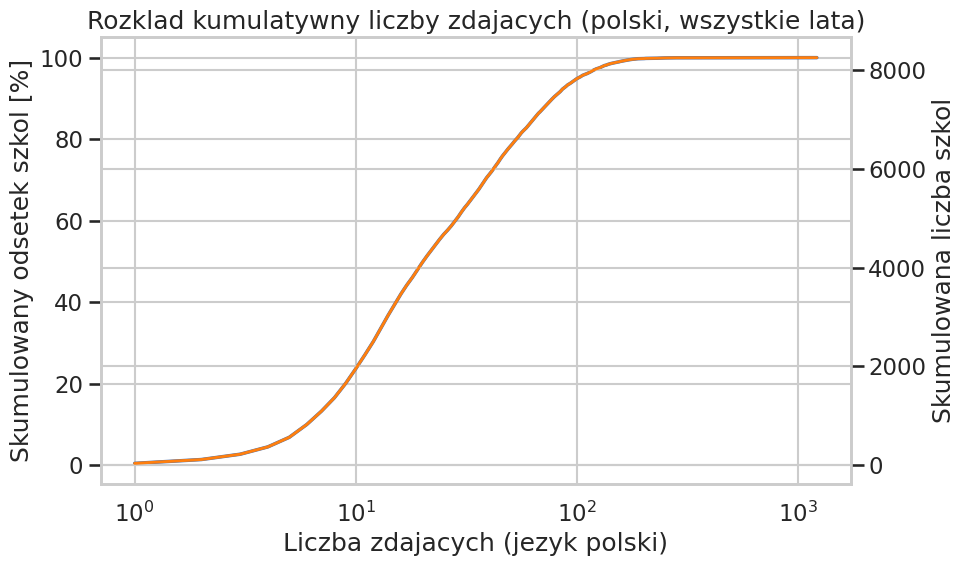

Uzyta kolumna liczby zdajacych (polski): ('jezyk polski', 'liczba zdajacych')
Liczba rekordow w df_egzaminy: 8,260
Przykladowe kolumny MultiIndex: [('meta', 'rok'), ('meta', 'id oke'), ('meta', 'wojewodztwo - nazwa'), ('meta', 'powiat - nazwa'), ('meta', 'gmina - nazwa')]


In [4]:
# Wykres kumulatywny tylko po liczbie zdajacych z jezyka polskiego.
students_pl = pd.to_numeric(df_egzaminy[polish_candidates_col], errors='coerce')
students_pl = students_pl.dropna()
students_pl = students_pl[students_pl > 0]

cdf = pd.DataFrame({'n_zdajacych_pl': np.sort(students_pl.to_numpy())})
cdf['cum_share_pct'] = (np.arange(1, len(cdf) + 1) / len(cdf)) * 100
cdf['cum_count'] = np.arange(1, len(cdf) + 1)

fig, ax1 = plt.subplots(figsize=(10, 6))
sns.lineplot(data=cdf, x='n_zdajacych_pl', y='cum_share_pct', ax=ax1, linewidth=2.5)
ax1.set_xlabel('Liczba zdajacych (jezyk polski)')
ax1.set_ylabel('Skumulowany odsetek szkol [%]')
ax1.set_xscale('log')  # wylacz, jesli chcesz os liniowa

ax2 = ax1.twinx()
sns.lineplot(data=cdf, x='n_zdajacych_pl', y='cum_count', ax=ax2, color='tab:orange', linewidth=2.0)
ax2.set_ylabel('Skumulowana liczba szkol')

plt.title('Rozklad kumulatywny liczby zdajacych (polski, wszystkie lata)')
plt.tight_layout()
plt.show()

print(f'Uzyta kolumna liczby zdajacych (polski): {polish_candidates_col}')
print(f'Liczba rekordow w df_egzaminy: {len(df_egzaminy):,}')
print(f'Przykladowe kolumny MultiIndex: {df_egzaminy.columns[:5].tolist()}')

## Mediana median szkol w kolejnych latach (PL, matematyka, EN)

Ten wykres pokazuje, jak zmienia sie w czasie mediana szkolnych median dla trzech glownych przedmiotow.

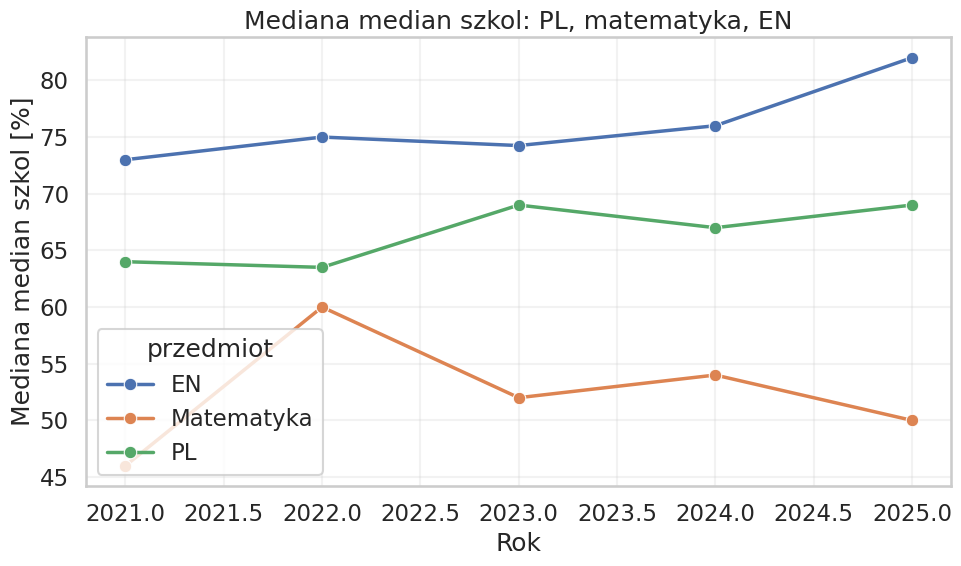

przedmiot,EN,Matematyka,PL
rok,,,
2021,73.00,46.0,64.0
2022,75.00,60.0,63.5
2023,74.25,52.0,69.0
2024,76.00,54.0,67.0
2025,82.00,50.0,69.0


In [5]:
def find_subject_median_col(subject_aliases: list[str]) -> tuple[str, str]:
    for col in df_egzaminy.columns:
        if not isinstance(col, tuple) or len(col) != 2:
            continue
        obszar, metryka = col
        obszar_n = normalize_text(obszar)
        metryka_n = normalize_text(metryka)
        if 'mediana' not in metryka_n:
            continue
        if any(alias in obszar_n for alias in subject_aliases):
            return col
    raise ValueError(f'Nie znaleziono kolumny mediany dla aliasow: {subject_aliases}')


col_pl = find_subject_median_col(['polski', 'jezyk polski'])
col_mat = find_subject_median_col(['matematyka'])
col_en = find_subject_median_col(['angielski', 'jezyk angielski'])

serie = []
for label, col in [('PL', col_pl), ('Matematyka', col_mat), ('EN', col_en)]:
    tmp = df_egzaminy[[('meta', 'rok'), col]].copy()
    tmp.columns = ['rok', 'mediana_szkoly']
    tmp['mediana_szkoly'] = pd.to_numeric(tmp['mediana_szkoly'], errors='coerce')
    tmp = tmp.dropna(subset=['mediana_szkoly'])
    summary = tmp.groupby('rok', as_index=False)['mediana_szkoly'].median()
    summary['przedmiot'] = label
    serie.append(summary)

mediana_median_rocznie = pd.concat(serie, ignore_index=True)
mediana_median_rocznie = mediana_median_rocznie.sort_values(['rok', 'przedmiot'])

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=mediana_median_rocznie,
    x='rok',
    y='mediana_szkoly',
    hue='przedmiot',
    marker='o',
    linewidth=2.5,
)
plt.xlabel('Rok')
plt.ylabel('Mediana median szkol [%]')
plt.title('Mediana median szkol: PL, matematyka, EN')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

mediana_median_rocznie.pivot(index='rok', columns='przedmiot', values='mediana_szkoly')

## Dalej

`df_egzaminy` jest gotowy ze sprawdzonym formatem oraz kolumnami 2-poziomowymi (`MultiIndex`).
Kolumna roku to `('meta', 'rok')` i mozesz na tym od razu robic dalsze analizy.

In [6]:
df_egzaminy.head()

obszar   meta                                                          \
metryka   rok id oke wojewodztwo - nazwa powiat - nazwa gmina - nazwa   
0        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
1        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
2        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
3        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
4        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   

obszar                                                                       \
metryka      typ gminy kod teryt gminy   rspo rodzaj placowki czy publiczna   
0        Gmina miejska         1461011  27152   dla młodzieży           Tak   
1        Gmina miejska         1461011  27351   dla młodzieży           Tak   
2        Gmina miejska         1461011  27789   dla młodzieży           Tak   
3        Gmina miejska         1461011  44013   dla młodzieży           Tak   
4        Gmina miejska         1461011  44015   dla młodzieży           Tak   

obszar   ...   jezyk rosyjski                                         \
metryka  ... wynik sredni (%) odchylenie standardowe (%) mediana (%)   
0        ...              NaN                        NaN         NaN   
1        ...              NaN                        NaN         NaN   
2        ...              NaN                        NaN         NaN   
3        ...              NaN                        NaN         NaN   
4        ...              NaN                        NaN         NaN   

obszar                  jezyk włoski                   \
metryka modalna (%) liczba zdajacych wynik sredni (%)   
0               NaN              NaN              NaN   
1               NaN              NaN              NaN   
2               NaN              NaN              NaN   
3               NaN              NaN              NaN   
4               NaN              NaN              NaN   

obszar                                                      \
metryka odchylenie standardowe (%) mediana (%) modalna (%)   
0                              NaN         NaN         NaN   
1                              NaN         NaN         NaN   
2                              NaN         NaN         NaN   
3                              NaN         NaN         NaN   
4                              NaN         NaN         NaN   

obszar                  meta  
metryka identyfikator szkoły  
0                        NaN  
1                        NaN  
2                        NaN  
3                        NaN  
4                        NaN  

[5 rows x 54 columns]

In [7]:
df_egzaminy.columns

MultiIndex([(            'meta',                        'rok'),
            (            'meta',                     'id oke'),
            (            'meta',        'wojewodztwo - nazwa'),
            (            'meta',             'powiat - nazwa'),
            (            'meta',              'gmina - nazwa'),
            (            'meta',                  'typ gminy'),
            (            'meta',            'kod teryt gminy'),
            (            'meta',                       'rspo'),
            (            'meta',            'rodzaj placowki'),
            (            'meta',              'czy publiczna'),
            (            'meta',               'nazwa szkoły'),
            (            'meta',                'miejscowosc'),
            (            'meta',                   'ulica nr'),
            (    'jezyk polski',           'liczba zdajacych'),
            (    'jezyk polski',           'wynik sredni (%)'),
            (    'jezyk polski', 'odchyl

In [8]:
# Podglad wybranej czesci kolumn MultiIndex (po sortowaniu osi kolumn).
df_egzaminy.sort_index(axis=1).loc[:, 'meta':'jezyk angielski']

0
1
2
3
4
...
8255
8256
8257
8258
8259
